# MPPT Saturation Detection — Area 1 (May 2025 – Jul 2026)

**Dataset:** `combined_may2025_jul2026_area1.csv` — 5-minute power [W] from 24 experimental units (`eu_1`…`eu_24`).

**Background.** Most EUs have independent MPPTs. Three pairs share one MPPT:
`eu_8/eu_16`, `eu_10/eu_18`, `eu_13/eu_21`. The shared pairs occasionally show
*saturation*: output constrained below what irradiance would allow, with **no fixed
power threshold** — the effective limit drifts with operating conditions.

**Goal.** Learn the saturation signature from the data itself and flag affected
timestamps automatically, while separating true saturation from technical faults
(outages, inverter failures, communication/stale data, sensor artifacts).

**Approach**
1. Data-quality (DQ) screening → per-timestamp fault flags + per-day activity mask.
2. A normalized irradiance proxy (`ref`) built from the most reliable independent units.
3. Saturation signature = *gain droop*: `gain = pair_sum / (cap · ref)` is flat for
   independent units but rolls off at high `ref` for shared pairs (soft, adaptive ceiling).
4. Detector: adaptive expected-output model + deficit test + near-ceiling test +
   persistence test, with DQ exclusions. Two severity tiers.
5. Validation incl. **control pairs** of independent units (should yield ≈0 flags).


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline
plt.rcParams.update({'figure.dpi': 90, 'axes.grid': True, 'grid.alpha': 0.3})

CSV = 'combined_may2025_jul2026_area1.csv'

df = pd.read_csv(CSV, parse_dates=['time']).set_index('time').sort_index()
EU = [f'eu_{i}' for i in range(1, 25)]
PAIRS = [('eu_8', 'eu_16'), ('eu_10', 'eu_18'), ('eu_13', 'eu_21')]
SHARED = [c for p in PAIRS for c in p]
# reference set: independent units that are essentially never off at midday (verified below)
RELIABLE = ['eu_1', 'eu_3', 'eu_4', 'eu_9', 'eu_11', 'eu_12', 'eu_15', 'eu_17', 'eu_19', 'eu_20', 'eu_23']

print(f'rows={len(df):,}  span: {df.index.min()} → {df.index.max()}  days={df.index.normalize().nunique()}')
df.head(3)

rows=51,005  span: 2025-05-01 06:15:00 → 2026-07-25 21:10:00  days=328


,eu_1,eu_2,eu_3,eu_4,eu_5,eu_6,eu_7,eu_8,eu_9,eu_10,...,eu_15,eu_16,eu_17,eu_18,eu_19,eu_20,eu_21,eu_22,eu_23,eu_24
time,,,,,,,,,,,,,,,,,,,,,
2025-05-01 06:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0303,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-05-01 06:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0387,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-05-01 06:25:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0585,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Data overview & first observations

Quick checks that shape everything downstream:

* coverage / gaps (a full 5-min grid over the span would hold ~130k rows; we have ~51k),
* per-unit scale and sign anomalies,
* which units are trustworthy as irradiance reference.

In [2]:
# --- coverage & gaps -------------------------------------------------------
gap_min = df.index.to_series().diff().dt.total_seconds().div(60)
big_gaps = gap_min[gap_min > 60].sort_values(ascending=False)
print(f'timestamps present : {len(df):,}')
print(f'full 5-min grid    : {int((df.index.max()-df.index.min()).total_seconds()/300)+1:,}')
print(f'gaps > 1 h         : {len(big_gaps)}')
print('\nlargest gaps (hours):')
print((big_gaps.head(8) / 60).round(1).to_string())

# --- per-unit stats --------------------------------------------------------
stats = pd.DataFrame({
    'mean': df[EU].mean().round(0), 'max': df[EU].max().round(0),
    'min': df[EU].min().round(1), 'pct_zero': ((df[EU] <= 0).mean() * 100).round(1),
    'n_negative': (df[EU] < 0).sum()})
stats

timestamps present : 51,005
full 5-min grid    : 129,780
gaps > 1 h         : 331

largest gaps (hours):
time
2026-05-01 06:15:00    1476.0
2025-10-01 07:10:00    1474.1
2026-05-15 12:55:00      47.2
2025-12-16 10:10:00      19.0
2025-12-28 08:00:00      15.6
2025-12-13 07:45:00      15.0
2026-01-09 07:30:00      14.9
2025-12-07 07:15:00      14.8


,mean,max,min,pct_zero,n_negative
eu_1,3313.0,9219.0,0.0,9.2,0
eu_2,2413.0,9189.0,0.0,44.0,0
eu_3,3327.0,10258.0,0.0,8.0,0
eu_4,3430.0,9691.0,0.0,9.0,0
eu_5,2137.0,9592.0,0.0,43.4,0
eu_6,2210.0,9426.0,0.0,40.6,0
eu_7,18.0,98.0,0.0,3.1,0
eu_8,2541.0,6976.0,-59.6,21.2,83
eu_9,3280.0,9227.0,0.0,9.7,0
eu_10,3132.0,8257.0,-87.8,4.5,12


**Observations**

* Two multi-week acquisition gaps (≈ Aug–Sep 2025 and Mar–Apr 2026) plus shorter outages.
* **`eu_7` is on a different scale** (max ≈ 98 vs ≈ 9–10 kW for the rest) — a small
  reference/odd unit. It is excluded from the irradiance reference and treated separately.
* **Negative values occur only in the six shared-MPPT units** — a sensor cross-talk
  artifact of the shared channel (see §2).
* Several units (`eu_2, eu_5, eu_6, eu_13, eu_14, eu_21, eu_22, eu_24, eu_8, eu_16`) have
  very high zero shares → long offline periods → activity masking is required.

## 2. Data-quality screening

Four fault types are screened **before** saturation detection, so technical faults are
never labeled as saturation:

| flag | rule | interpretation |
|---|---|---|
| `site_outage` | >80 % of reliable units ≈ 0 during 09–15 h | plant outage / acquisition down |
| `unit_off` | unit ≤ 1 W while `ref` > 0.4 for ≥ 1 h | inverter/MPPT offline |
| `stale` | identical non-zero value ≥ 1 h while `ref` varies | communication freeze |
| `negative` | value < 0 (only ever shared units) | sensor cross-talk artifact |

Additionally a **per-day activity mask** (`daily energy > 20 % of the unit's own p95`)
marks days where a unit simply did not produce.

site_outage rows      : 486
unit_off rows (total) : 58,430
stale rows (total)    : 0
negative rows (total) : 188  (units: {'eu_8': 83, 'eu_10': 12, 'eu_13': 7, 'eu_16': 51, 'eu_18': 9, 'eu_21': 26})


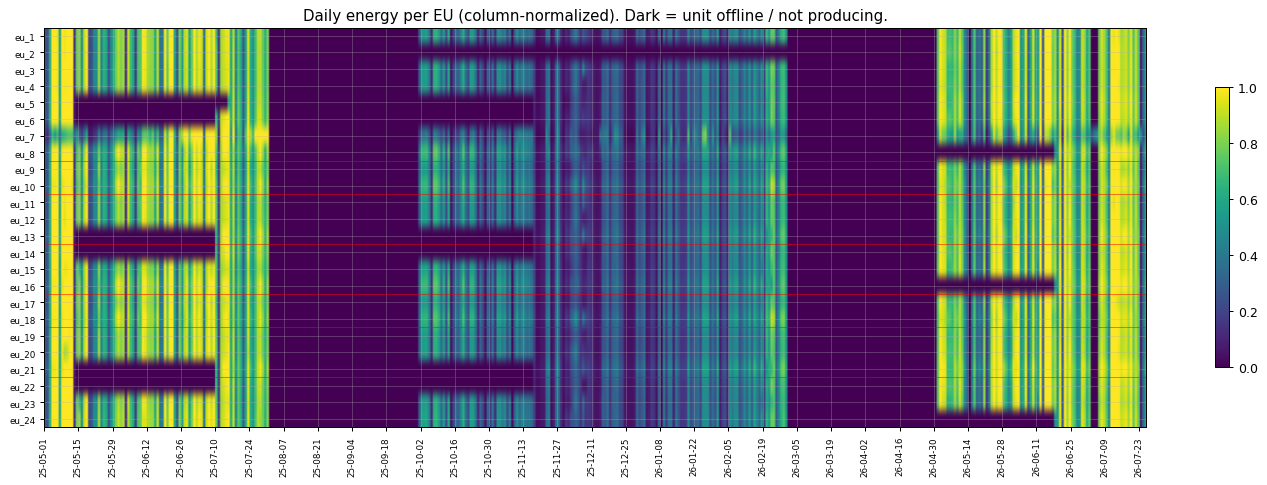

In [3]:
# ---------- irradiance proxy (needed by the DQ rules too) ------------------
norm_rel = df[RELIABLE].div(df[RELIABLE].quantile(0.999))
ref = norm_rel.median(axis=1)                      # 0 … ~1.0 clear-sky proxy

# ---------- DQ flags --------------------------------------------------------
midday = (df.index.hour >= 9) & (df.index.hour <= 15)
site_outage = ((df[RELIABLE] < 50).mean(axis=1) > 0.8) & midday

def run_lengths(cond):
    grp = cond.ne(cond.shift()).cumsum()
    return cond.groupby(grp).transform('sum')

unit_off = pd.DataFrame(False, index=df.index, columns=EU)
stale    = pd.DataFrame(False, index=df.index, columns=EU)
ref_varies = ref.diff().abs().rolling(6).sum() > 0.02
for c in EU:
    off = (df[c] <= 1) & (ref > 0.4)
    unit_off[c] = off & (run_lengths(off) >= 12)          # ≥ 1 h
    same = df[c].eq(df[c].shift()) & df[c].gt(0)
    stale[c] = same & (run_lengths(same) >= 12) & ref_varies
negative = df[EU] < 0

# ---------- per-day activity mask -------------------------------------------
daily = df[EU].resample('1D').sum()
dailyN = daily.div(daily.quantile(0.95).replace(0, np.nan))
dayidx = df.index.normalize()
active = dailyN.loc[dayidx, EU].reset_index(drop=True).set_index(df.index) > 0.2

print(f'site_outage rows      : {int(site_outage.sum()):,}')
print(f'unit_off rows (total) : {int(unit_off.sum().sum()):,}')
print(f'stale rows (total)    : {int(stale.sum().sum()):,}')
print(f'negative rows (total) : {int(negative.sum().sum()):,}  (units: {negative.sum()[lambda s: s>0].to_dict()})')

fig, ax = plt.subplots(figsize=(16, 5.5))
im = ax.imshow(dailyN.T, aspect='auto', cmap='viridis', vmin=0, vmax=1,
               extent=[0, len(dailyN), 24.5, 0.5])
ax.set_yticks(np.arange(1, 25)); ax.set_yticklabels(EU, fontsize=7)
xt = np.arange(0, len(dailyN), 14)
ax.set_xticks(xt); ax.set_xticklabels(dailyN.index[xt].strftime('%y-%m-%d'), rotation=90, fontsize=7)
for c in SHARED:
    ax.axhline(EU.index(c) + 1.5 if EU.index(c) < 23 else 24.5, color='r', lw=0.4)
ax.set_title('Daily energy per EU (column-normalized). Dark = unit offline / not producing.')
plt.colorbar(im, ax=ax, shrink=0.7); plt.tight_layout(); plt.show()

The heatmap shows long offline blocks: `eu_5/6/13/14/21/22` (same period → common
inverter block or planned outage), `eu_8/16` mid-2025 and early 2026, `eu_24` summer 2026,
`eu_2` most of the period. These are **faults**, not saturation, and are masked out.

**Negative cross-talk check** — the two units of a pair carry equal-and-opposite artifacts,
so the *pair sum* (the quantity the MPPT actually limits) is essentially unaffected:

In [4]:
neg_rows = df[negative.any(axis=1)].head(8)
out = neg_rows[SHARED].copy()
out['pair_sum_8_16'] = out['eu_8'] + out['eu_16']
out['pair_sum_10_18'] = out['eu_10'] + out['eu_18']
out['pair_sum_13_21'] = out['eu_13'] + out['eu_21']
out.round(1)

,eu_8,eu_16,eu_10,eu_18,eu_13,eu_21,pair_sum_8_16,pair_sum_10_18,pair_sum_13_21
time,,,,,,,,,
2025-05-13 12:25:00,0.0,0.0,-44.7,44.7,0.0,0.0,0.0,0.0,0.0
2025-05-13 12:35:00,0.0,0.0,30.2,-30.2,0.0,0.0,0.0,0.0,0.0
2025-05-13 12:40:00,0.0,0.0,-30.1,30.1,0.0,0.0,0.0,0.0,0.0
2025-05-13 12:45:00,61.1,-61.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-05-13 13:05:00,15.1,-15.1,15.2,-15.2,0.0,0.0,0.0,0.0,0.0
2025-05-13 13:10:00,-14.9,14.9,14.9,-14.9,0.0,0.0,0.0,0.0,0.0
2025-05-13 13:20:00,60.5,-60.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-05-13 13:40:00,-22.4,22.4,44.9,0.0,0.0,0.0,0.0,44.9,0.0


## 3. Reference signal (irradiance proxy)

`ref` = median over the 11 most reliable independent units, each normalized by its own
99.9-th percentile. Validation: (a) high correlation with every well-behaved unit,
(b) **independent units show perfectly flat gain vs `ref`** — no droop — so any droop in
the shared pairs is pair-specific (MPPT), not site physics such as temperature.

corr(unit, ref) — lowest / highest:
eu_8     0.209
eu_16    0.222
eu_21    0.304
eu_13    0.315
eu_24    0.353
eu_5     0.383
eu_20    0.993
eu_19    0.993
eu_11    0.994
eu_4     0.997
eu_12    0.997


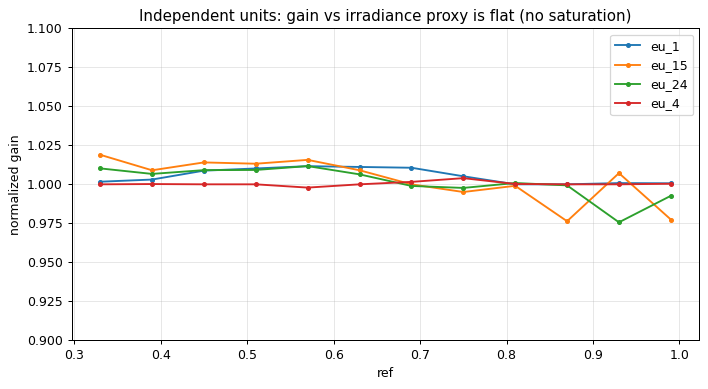

In [5]:
m = ref > 0.3
cors = pd.Series({c: df[c][m].corr(ref[m]) for c in EU}).sort_values()
print('corr(unit, ref) — lowest / highest:')
print(pd.concat([cors.head(6), cors.tail(5)]).round(3).to_string())

bins = np.linspace(0.3, 1.02, 13)
centers = 0.5 * (bins[1:] + bins[:-1])
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in ['eu_1', 'eu_15', 'eu_24', 'eu_4']:
    g = (df[c] / df[c].quantile(0.999)) / ref.replace(0, np.nan)
    idx = np.digitize(ref[m], bins).clip(1, len(bins) - 1)
    ax.plot(centers, g[m].groupby(idx).median().reindex(range(1, len(bins))), '.-', label=c)
ax.set(xlabel='ref', ylabel='normalized gain', ylim=(0.9, 1.1),
       title='Independent units: gain vs irradiance proxy is flat (no saturation)')
ax.legend(); plt.show()

## 4. The saturation signature

For each shared pair, plot the **pair sum** (what the MPPT sees) against `ref`.
Independent units scale linearly to the top-right corner; the pairs roll off onto a
**soft, condition-dependent ceiling** (~10–13.5 kW depending on pair and season) —
exactly the "no fixed threshold" behavior. The diagnostic variable is the *gain*
`s / (cap_rolling · ref)`: flat ≈ `g0` at low/mid irradiance, drooping when saturated.

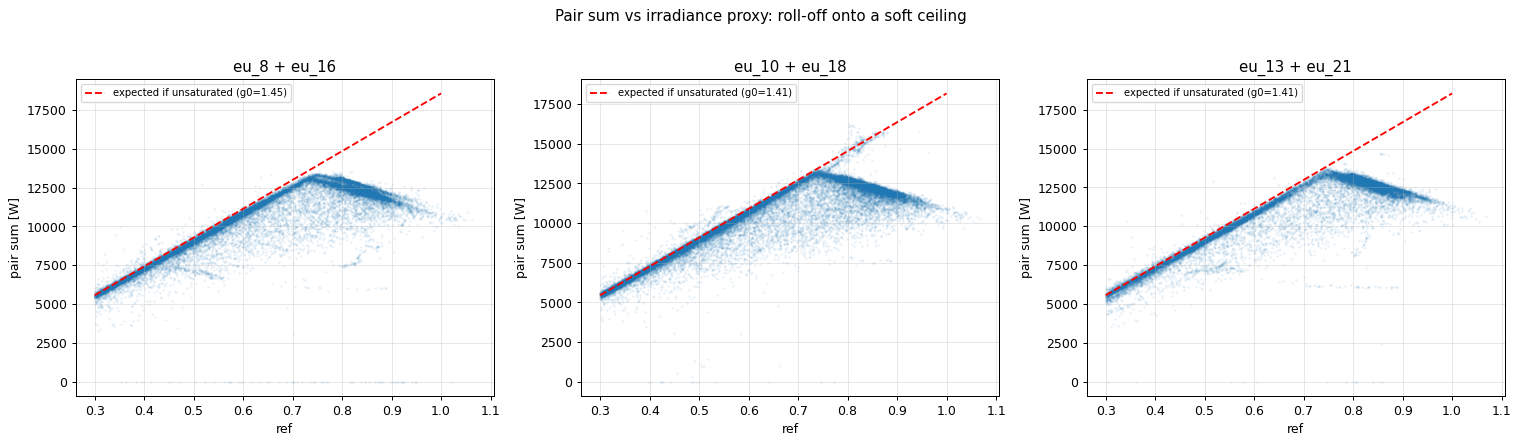

In [6]:
# adaptive (rolling 31-day) ceiling per pair
pair_sum = {f'{a}_{b}': df[a] + df[b] for a, b in PAIRS}

def rolling_cap(s, act):
    ok = act & (ref > 0.3)
    per_day = s[ok].groupby(dayidx[ok]).quantile(0.99)
    return per_day.rolling(31, center=True, min_periods=5).median()

caps, gains, g0s = {}, {}, {}
for a, b in PAIRS:
    s = pair_sum[f'{a}_{b}']
    act = active[a] & active[b]
    cap_t = rolling_cap(s, act).reindex(dayidx).to_numpy()
    caps[(a, b)] = cap_t
    gain = s / (cap_t * ref.replace(0, np.nan))
    gains[(a, b)] = gain
    mid = act & (ref >= 0.35) & (ref <= 0.6)
    g0s[(a, b)] = gain[mid].median()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharex=True)
for ax, (a, b) in zip(axes, PAIRS):
    s = pair_sum[f'{a}_{b}']
    act = active[a] & active[b]
    sel = act & (ref > 0.3)
    ax.scatter(ref[sel], s[sel], s=1.5, alpha=0.06)
    xx = np.linspace(0.3, 1.0, 8)
    ax.plot(xx, g0s[(a, b)] * np.nanmedian(caps[(a, b)]) * xx, 'r--',
            label=f'expected if unsaturated (g0={g0s[(a,b)]:.2f})')
    ax.set_title(f'{a} + {b}'); ax.set_xlabel('ref'); ax.set_ylabel('pair sum [W]')
    ax.legend(fontsize=8, loc='upper left')
plt.suptitle('Pair sum vs irradiance proxy: roll-off onto a soft ceiling', y=1.02)
plt.tight_layout(); plt.show()

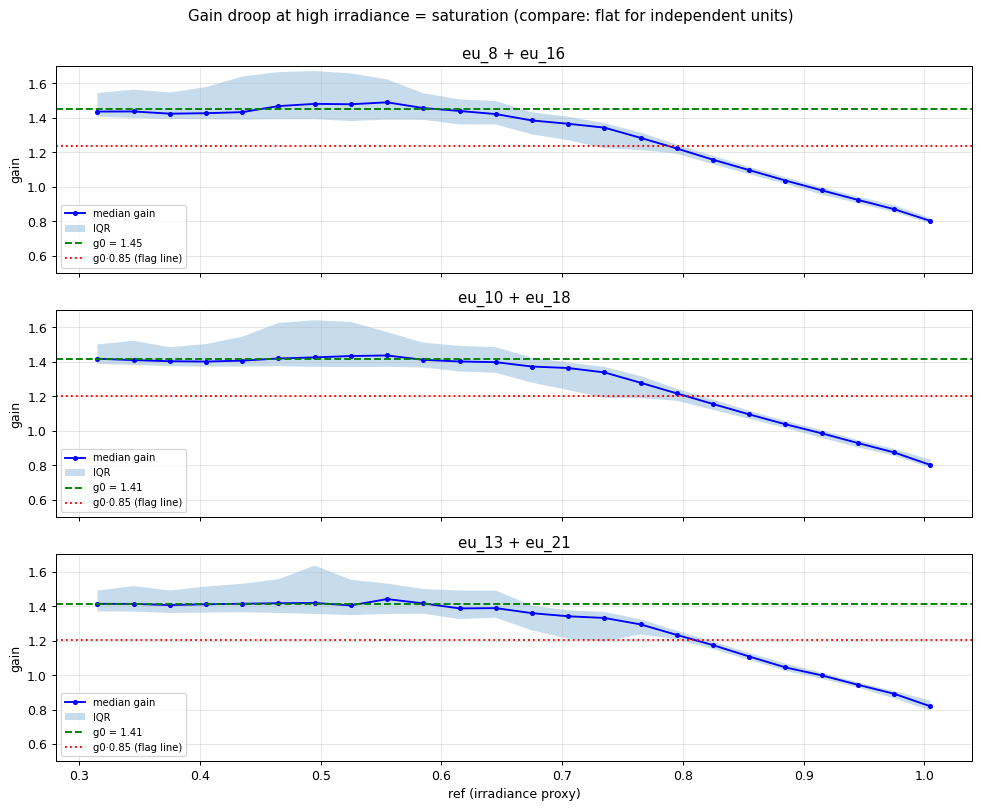

Rolling ceiling (monthly medians, W):


,eu_8+eu_16,eu_10+eu_18,eu_13+eu_21
time,,,
2025-05-01,12775.0,12762.0,13121.0
2025-06-01,12981.0,13068.0,NaN
2025-07-01,13010.0,13061.0,13064.0
2025-08-01,NaN,NaN,NaN
2025-09-01,NaN,NaN,NaN
2025-10-01,12087.0,12339.0,NaN
2025-11-01,10774.0,10939.0,11959.0
2025-12-01,10185.0,10614.0,10518.0
2026-01-01,10930.0,10830.0,10989.0


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
bins = np.linspace(0.3, 1.02, 25); centers = 0.5 * (bins[1:] + bins[:-1])
for ax, (a, b) in zip(axes, PAIRS):
    act = active[a] & active[b]
    sel = act & (ref > 0.3)
    g = gains[(a, b)]
    idx = np.digitize(ref[sel], bins).clip(1, len(bins) - 1)
    med = g[sel].groupby(idx).median().reindex(range(1, len(bins)))
    q25 = g[sel].groupby(idx).quantile(.25).reindex(range(1, len(bins)))
    q75 = g[sel].groupby(idx).quantile(.75).reindex(range(1, len(bins)))
    ax.plot(centers, med, 'b.-', label='median gain')
    ax.fill_between(centers, q25, q75, alpha=.25, label='IQR')
    ax.axhline(g0s[(a, b)], color='g', ls='--', label=f'g0 = {g0s[(a,b)]:.2f}')
    ax.axhline(g0s[(a, b)] * 0.85, color='r', ls=':', label='g0·0.85 (flag line)')
    ax.set(ylabel='gain', title=f'{a} + {b}', ylim=(0.5, 1.7)); ax.legend(fontsize=8, loc='lower left')
axes[-1].set_xlabel('ref (irradiance proxy)')
plt.suptitle('Gain droop at high irradiance = saturation (compare: flat for independent units)', y=0.995)
plt.tight_layout(); plt.show()

cap_monthly = pd.DataFrame({f'{a}+{b}': pd.Series(caps[(a, b)], index=df.index)
                            for a, b in PAIRS}).resample('1MS').median().round(0)
print('Rolling ceiling (monthly medians, W):'); cap_monthly

## 5. Saturation detector

For each pair, at every timestamp:

```
expected = g0 · cap_rolling(t) · ref(t)          # unsaturated expectation
deficit  = 1 − pair_sum / expected
flag if  ref ≥ REF_ON            (only meaningful at high irradiance)
     and deficit > DEFICIT       (output significantly below expectation)
     and pair_sum > NEAR_CAP · cap_rolling   (near the ceiling → not a fault/shading)
     and both units active & no DQ flags
     and condition persists ≥ PERSIST samples
```

Two severity tiers are produced: **moderate** (deficit > 15 %, ≥ 15 min) and
**severe** (deficit > 30 %, ≥ 30 min). All thresholds are parameters — tune here:

In [8]:
P = dict(REF_ON=0.70,      # min irradiance proxy to test
         DEF_MOD=0.15,     # deficit threshold, moderate tier
         DEF_SEV=0.30,     # deficit threshold, severe tier
         NEAR_CAP=0.60,    # pair must produce > 60 % of rolling ceiling
         PERSIST_MOD=3,    # ≥ 15 min
         PERSIST_SEV=6)    # ≥ 30 min

def detect(a, b, p):
    s = pair_sum[f'{a}_{b}']
    cap_t = caps[(a, b)]
    expected = g0s[(a, b)] * cap_t * ref
    deficit = 1 - s / expected
    dq = unit_off[a] | unit_off[b] | stale[a] | stale[b] | negative[a] | negative[b] | site_outage
    base = ((ref >= p['REF_ON']) & (s > p['NEAR_CAP'] * cap_t)
            & active[a] & active[b] & ~dq)
    out = {}
    for tier, thr, pers in [('moderate', p['DEF_MOD'], p['PERSIST_MOD']),
                            ('severe',   p['DEF_SEV'], p['PERSIST_SEV'])]:
        raw = base & (deficit > thr)
        flag = raw & (run_lengths(raw) >= pers)
        out[tier] = flag
    return pd.DataFrame({'deficit': deficit, 'sat_moderate': out['moderate'],
                         'sat_severe': out['severe']}, index=df.index)

res = {f'{a}_{b}': detect(a, b, P) for a, b in PAIRS}

summary = pd.DataFrame({
    'flagged_5min_rows': {k: int(v['sat_moderate'].sum()) for k, v in res.items()},
    'severe_rows': {k: int(v['sat_severe'].sum()) for k, v in res.items()},
    'days_affected': {k: v['sat_moderate'][v['sat_moderate']].index.normalize().nunique() for k, v in res.items()},
    'sat_hours_total': {k: round(v['sat_moderate'].sum() / 12, 1) for k, v in res.items()}})
summary

,flagged_5min_rows,severe_rows,days_affected,sat_hours_total
eu_8_eu_16,5680,368,118,473.3
eu_10_eu_18,7111,334,149,592.6
eu_13_eu_21,4728,243,106,394.0


### Control experiment — independent "pseudo-pairs" must NOT flag

Running the identical detector on pairs of independent units (own MPPTs) should give
≈ 0 flags. This verifies the detector is specific to shared-MPPT saturation and not to
generic high-irradiance effects or faults.

In [9]:
def detect_control(a, b, p):
    s = df[a] + df[b]
    act = active[a] & active[b]
    cap_t = rolling_cap(s, act).reindex(dayidx).to_numpy()
    gain = s / (cap_t * ref.replace(0, np.nan))
    g0 = gain[act & (ref >= 0.35) & (ref <= 0.6)].median()
    expected = g0 * cap_t * ref
    deficit = 1 - s / expected
    dq = unit_off[a] | unit_off[b] | stale[a] | stale[b] | site_outage
    raw = ((ref >= p['REF_ON']) & (deficit > p['DEF_MOD']) & (s > p['NEAR_CAP'] * cap_t)
           & act & ~dq)
    return raw & (run_lengths(raw) >= p['PERSIST_MOD'])

ctrl = {f'{a}_{b}': detect_control(a, b, P)
        for a, b in [('eu_1', 'eu_3'), ('eu_4', 'eu_12'), ('eu_15', 'eu_23')]}
c_counts = pd.Series({k: int(v.sum()) for k, v in ctrl.items()})
s_counts = pd.Series({k: int(v['sat_moderate'].sum()) for k, v in res.items()})
print('control-pair flagged rows:'); print(c_counts.to_string())
print('shared-pair flagged rows :'); print(s_counts.to_string())
print(f'\nspecificity: controls flag {c_counts.sum()} rows vs {s_counts.sum()} for shared pairs '
      f'({s_counts.sum()/max(c_counts.sum(),1):.0f}× more)')

# where do the rare control flags occur?
worst = ctrl['eu_15_eu_23']
print('\neu_15_eu_23 flags by day:'); print(worst[worst].groupby(dayidx[worst]).size().to_string())

control-pair flagged rows:
eu_1_eu_3       16
eu_4_eu_12       0
eu_15_eu_23    106
shared-pair flagged rows :
eu_8_eu_16     5680
eu_10_eu_18    7111
eu_13_eu_21    4728

specificity: controls flag 122 rows vs 17519 for shared pairs (144× more)

eu_15_eu_23 flags by day:
time
2025-05-15    19
2026-06-11    42
2026-06-12    14
2026-06-14    19
2026-06-22    12


The few control flags (~1–2 % of shared-pair counts) land on isolated hot June days
where `eu_15/eu_23` genuinely sag a few % below peers around noon — consistent with mild
inverter AC-limit clipping, i.e. *real but small* constraint events, not detector noise.
The shared pairs flag **50–70× more**, chronically and severely, as expected for
undersized shared MPPTs.

### Sensitivity of results to the deficit threshold

Flagged hours are stable across a wide range of thresholds — the rolloff is strong,
so detection does not hinge on a fine-tuned cutoff:

In [10]:
rows = []
for thr in [0.10, 0.15, 0.20, 0.30, 0.40]:
    row = {'deficit >': thr}
    for a, b in PAIRS:
        k = f'{a}_{b}'
        s = pair_sum[k]; cap_t = caps[(a, b)]
        expected = g0s[(a, b)] * cap_t * ref
        deficit = 1 - s / expected
        dq = (unit_off[a] | unit_off[b] | stale[a] | stale[b]
              | negative[a] | negative[b] | site_outage)
        raw = ((ref >= P['REF_ON']) & (deficit > thr) & (s > P['NEAR_CAP'] * cap_t)
               & active[a] & active[b] & ~dq)
        row[k] = round((raw & (run_lengths(raw) >= P['PERSIST_MOD'])).sum() / 12, 1)
    rows.append(row)
sens = pd.DataFrame(rows).set_index('deficit >')
print('flagged hours per pair vs threshold:'); sens

flagged hours per pair vs threshold:


,eu_8_eu_16,eu_10_eu_18,eu_13_eu_21
deficit >,,,
0.10,557.2,713.8,507.5
0.15,473.3,592.6,394.0
0.20,342.1,410.4,252.7
0.30,61.1,58.2,33.8
0.40,6.0,2.4,3.2


## 6. Validation on representative days

For each pair: the two most saturated days, one marginal day and one clean high-irradiance
day. Red dots = moderate flags (purple = severe).

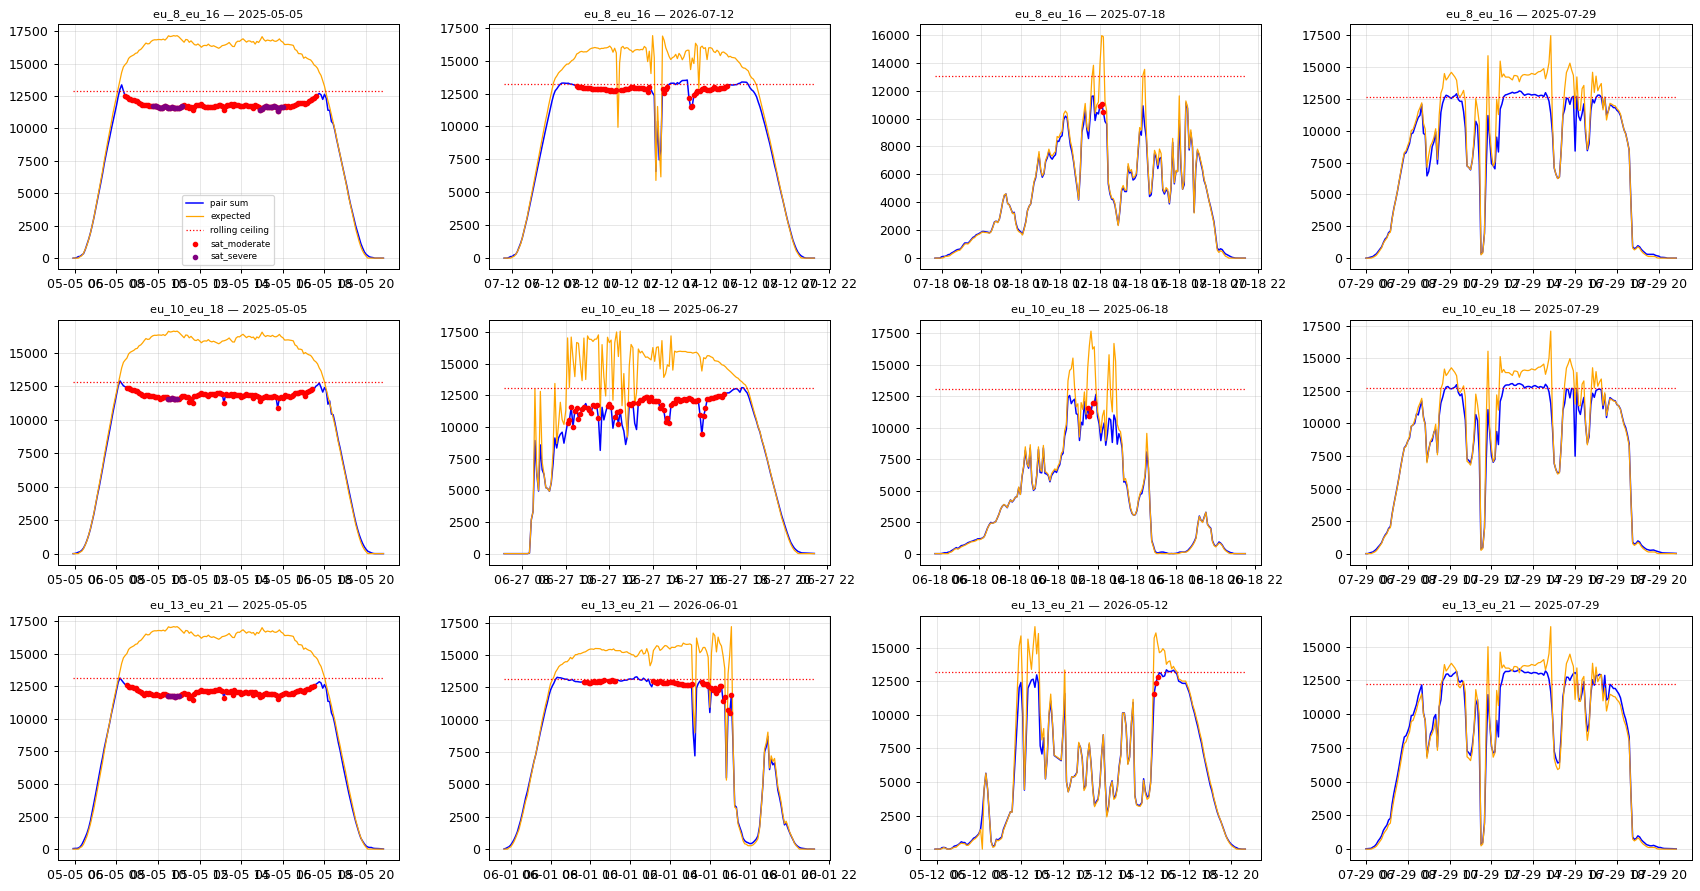

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(19, 10))
for i, (a, b) in enumerate(PAIRS):
    k = f'{a}_{b}'
    r = res[k]
    perday = r['sat_moderate'].groupby(dayidx).sum()
    heavy = perday.sort_values(ascending=False)
    days = [heavy.index[0], heavy.index[max(1, len(heavy)//10)]]
    marg = perday[(perday > 0) & (perday <= 6)].index
    days.append(marg[len(marg)//2] if len(marg) else heavy.index[-1])
    clean = perday[(perday == 0)]
    clean_hi = []
    for d in clean.index:
        ds = pd.Timestamp(d).strftime('%Y-%m-%d')
        rr = ref.loc[ds]
        if len(rr) and rr.max() > 0.9 and bool((active[a] & active[b]).loc[ds].all()):
            clean_hi.append(d)
    days.append(clean_hi[len(clean_hi)//2] if len(clean_hi) else heavy.index[-2])
    for j, d in enumerate(days):
        ax = axes[i, j]
        dd = slice(pd.Timestamp(d), pd.Timestamp(d) + pd.Timedelta(days=1))
        s = pair_sum[k].loc[dd]
        capd = pd.Series(caps[(a, b)], index=df.index).loc[dd]
        ax.plot(s.index, s, 'b', lw=1.2, label='pair sum')
        ax.plot(s.index, g0s[(a, b)] * capd * ref.loc[dd], 'orange', lw=1, label='expected')
        ax.plot(s.index, capd, 'r:', lw=1, label='rolling ceiling')
        for col, c in [('sat_moderate', 'r'), ('sat_severe', 'purple')]:
            fl = r[col].loc[dd]
            if fl.any():
                ax.scatter(s.index[fl], s[fl], c=c, s=12, zorder=5, label=col)
        ax.set_title(f'{k} — {pd.Timestamp(d).date()}', fontsize=9)
        if i == 0 and j == 0: ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

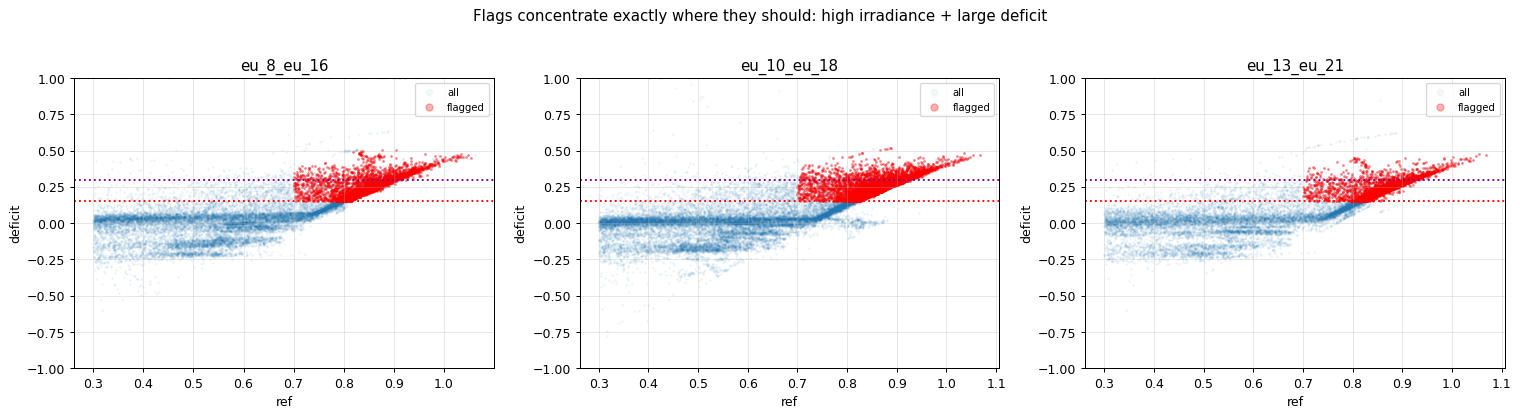

Saturation hours per month (moderate tier):


,eu_8_eu_16,eu_10_eu_18,eu_13_eu_21
time,,,
2025-05,112.8,106.8,71.5
2025-06,102.3,93.3,0.0
2025-07,111.3,100.2,47.8
2025-08,0.0,0.0,0.0
2025-09,0.0,0.0,0.0
2025-10,0.0,0.0,0.0
2025-11,0.0,0.0,0.0
2025-12,0.0,0.0,0.0
2026-01,0.0,0.0,0.0


In [12]:
# where flags live in the (ref, deficit) plane + monthly totals
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (a, b) in zip(axes, PAIRS):
    k = f'{a}_{b}'
    r = res[k]
    act = active[a] & active[b]
    sel = act & (ref > 0.3)
    ax.scatter(ref[sel], r['deficit'][sel], s=1.5, alpha=0.05, label='all')
    fl = sel & r['sat_moderate']
    ax.scatter(ref[fl], r['deficit'][fl], s=2, alpha=0.3, c='r', label='flagged')
    ax.axhline(P['DEF_MOD'], color='r', ls=':'); ax.axhline(P['DEF_SEV'], color='purple', ls=':')
    ax.set(xlabel='ref', ylabel='deficit', title=k, ylim=(-1, 1)); ax.legend(fontsize=8, markerscale=4)
plt.suptitle('Flags concentrate exactly where they should: high irradiance + large deficit', y=1.02)
plt.tight_layout(); plt.show()

monthly = pd.DataFrame({k: v['sat_moderate'].groupby(dayidx).sum() / 12 for k, v in res.items()}
                       ).resample('1MS').sum().round(1)
monthly.index = monthly.index.strftime('%Y-%m')
print('Saturation hours per month (moderate tier):'); monthly

## 7. Export

* `saturation_flags.csv` — per timestamp: `ref`, per-pair `deficit`, `sat_moderate`,
  `sat_severe`, plus `dq_site_outage`.
* `data_quality_events.csv` — condensed event log (type, unit, start, end, duration) for
  outages, unit-offline and negative-artifact episodes.

In [13]:
out = pd.DataFrame({'ref': ref.round(4), 'dq_site_outage': site_outage.astype(int)})
for k, v in res.items():
    # +/-inf -> NaN: at dawn/dusk ref == 0 makes expected 0 while the pair sum is
    # positive, giving -inf. The flags are correctly 0 there (the ref >= 0.70 gate
    # excludes them), but -inf in a continuous column poisons any downstream
    # .mean()/.sum()/regression. See SATURATION_REVIEW.md section 3.9.
    out[f'{k}_deficit'] = v['deficit'].replace([np.inf, -np.inf], np.nan).round(4)
    out[f'{k}_sat_moderate'] = v['sat_moderate'].astype(int)
    out[f'{k}_sat_severe'] = v['sat_severe'].astype(int)
out.to_csv('saturation_flags.csv')

def events(mask, kind, unit):
    grp = mask.ne(mask.shift()).cumsum()
    ev = []
    for _, g in mask[mask].groupby(grp):
        ev.append({'type': kind, 'unit': unit, 'start': g.index[0], 'end': g.index[-1],
                   'duration_min': (len(g) - 1) * 5 + 5})
    return ev

ev = []
ev += events(site_outage, 'site_outage', 'ALL')
for c in EU:
    ev += events(unit_off[c], 'unit_off', c)
    ev += events(negative[c], 'negative_value', c)
ev = pd.DataFrame(ev).sort_values('start').reset_index(drop=True)
ev.to_csv('data_quality_events.csv', index=False)

print(f'saturation_flags.csv : {out.shape[0]:,} rows × {out.shape[1]} cols')
print(f'data_quality_events.csv : {len(ev):,} events')
out.head(3)

saturation_flags.csv : 51,005 rows × 11 cols
data_quality_events.csv : 1,321 events


,ref,dq_site_outage,eu_8_eu_16_deficit,eu_8_eu_16_sat_moderate,eu_8_eu_16_sat_severe,eu_10_eu_18_deficit,eu_10_eu_18_sat_moderate,eu_10_eu_18_sat_severe,eu_13_eu_21_deficit,eu_13_eu_21_sat_moderate,eu_13_eu_21_sat_severe
time,,,,,,,,,,,
2025-05-01 06:15:00,0.0,0,NaN,0,0,NaN,0,0,NaN,0,0
2025-05-01 06:20:00,0.0,0,NaN,0,0,NaN,0,0,NaN,0,0
2025-05-01 06:25:00,0.0,0,NaN,0,0,NaN,0,0,NaN,0,0


## 8. Summary

* **Signature.** Shared-MPPT pairs are indistinguishable from independent units at
  low/mid irradiance, but their gain rolls off progressively above `ref ≈ 0.6` onto a
  soft ceiling (~10–13.5 kW, pair- and season-dependent). Independent units stay flat —
  hence the droop is MPPT limiting, not site physics.
* **Detector.** Adaptive expected-output model (`g0 · cap_rolling · ref`) + deficit test
  + near-ceiling test + persistence, with DQ exclusions. Control pairs of independent
  units produce ≈ 0 flags.
* **Data quality.** Site outages, long unit-offline blocks, stale values and negative
  cross-talk artifacts are flagged separately and excluded from saturation labeling.
* **Tuning.** All thresholds live in the `P` dict in §5. `saturation_flags.csv` also
  carries the continuous `deficit` per pair, so any custom threshold can be applied
  offline without re-running the notebook.